For free fermionic systems $H=\sum_{1\leq i,j\leq N}h_{ij}c_i^\dagger c_j$, we define the $(N+1)\times(N+1)$ one-body density matrix $P$:
$$
P_{ab} = \mathrm{Tr}(\rho\, c_b^\dagger c_a) \\
P_{0b} = \mathrm{Tr}(\rho\, B_E c_b) \\
P_{a0} = \mathrm{Tr}(\rho\, c_a^\dagger B_E) \\
P_{00} = \mathrm{Tr}(\rho\, B_E B_E^\dagger)
$$

The equation of motion of $P$ is
$$
dP/dt = PA + A^\dagger P
$$
where 
$$
A_{00} = i\omega \\ 
A_{a0} = i \alpha f(t) \\
A_{0b} = i \alpha f(t) \\
A_{ab} = i h_{ab}
$$


N = 5 beta = 1 Gibbs state energy = -1.673425341391092


100%|██████████| 500/500 [00:40<00:00, 12.33it/s]


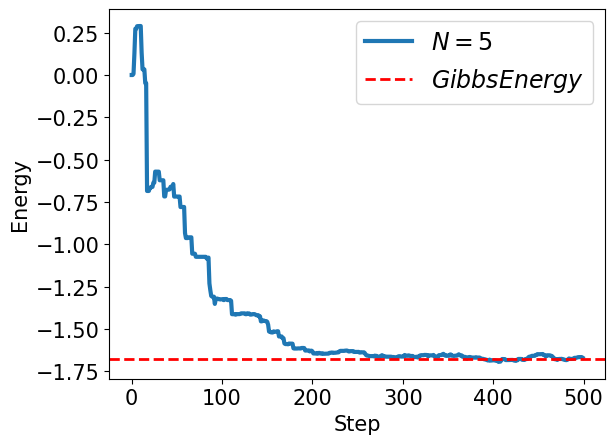

In [9]:
#This part of code is used to simulate the dynamics of P and compute the energy

import numpy as np, random
from scipy.linalg import expm, sinm, cosm
from tqdm import tqdm
import matplotlib.pyplot as plt

# Gaussian function
def f(t):
    return (2*np.pi)**(-1/4) * sigma**(-0.5) * np.exp(-t*t/(4*sigma*sigma))


def rhs(P, t, f):

    A0 = np.zeros((N + 1, N + 1), dtype=complex)
    A0[0, 0] = 1j * omega
    A0[0, k] = A0[0, k] + 1j * alpha * f(t)
    A0[k, 0] = A0[k, 0] + 1j * alpha * f(t)
    A0[1:N + 1, 1:N + 1] = 1j * h

    return (P @ A0 + A0.conj().T @ P)


def rk4_step(P, t, dt, f):
    k1 = rhs(P, t, f)
    k2 = rhs(P + 0.5 * dt * k1, t + 0.5 * dt, f)
    k3 = rhs(P + 0.5 * dt * k2, t + 0.5 * dt, f)
    k4 = rhs(P + dt * k3, t + dt, f)
    
    return P + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    

def solve_matrix_ode(P0, f, t0, t_end, dt):
    P = P0.copy()
    t = t0
    for _ in range(steps):
        P = rk4_step(P, t, dt, f)
        t += dt

    return P 

#parameter settings
N      = 5
beta   = 1
alpha  = 0.3
sigma  = 5*beta
Ss     = 10*sigma
dt     = 0.01*sigma
steps  = 2*round(Ss/dt) + 1
Nstep  = 500
energy = np.zeros(Nstep)


P = (np.eye(N+1)).astype(complex)
h = (np.eye(N, k=1) + np.eye(N, k=-1)).astype(complex)

# Gibbs state energy
Gibbsenergy = np.real(np.sum(h*np.linalg.inv(expm(beta*h)+np.eye(N)))) 
# Ground state energy
Groundenergy = np.real(np.sum(np.absolute(np.linalg.eigvals(h)))-np.sum(np.linalg.eigvals(h)))/2 

print('N =', N, 'beta =', beta, 'Gibbs state energy =', Gibbsenergy )

for kstep in tqdm(range(Nstep)):  

    omega = random.uniform(-2, 2) 
    k     = random.randint(1, N)
    P[0, :] = 0
    P[:, 0] = 0
    P[0, 0]  = np.exp(-beta * omega / 2) / (np.exp(beta * omega / 2) + np.exp(-beta * omega / 2))


    #print('Step =',kstep,' omega =',omega,' State energy =', np.real(np.sum(h*P[1:N+1,1:N+1])))
    
    energy[kstep] = np.real(np.sum(h * P[1:N + 1, 1:N + 1]))
    t = -Ss
    P = solve_matrix_ode(P, f, -Ss, Ss, dt)
    

plt.plot(energy, linewidth=3, label=r'$N=5$')
plt.axhline(y=Gibbsenergy, color='r', linestyle='--', linewidth=2, label=r'$Gibbs Energy$')
plt.xlabel(r'Step', fontsize=15)
plt.ylabel(r'Energy', fontsize=15)
plt.legend(fontsize=17)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

In [34]:
#This part of code is for computing the gap for f(t)=Constant, much faster than f(t)=gaussian

from numpy import linalg as LA
import numpy as np
from scipy.sparse import csr_matrix, kron
from scipy.sparse.linalg import expm

for N in range(2,20):
    
    #parameter settings
    beta   = 1
    alpha  = 0.1
    sigma  = 5*beta
    Ss     = 5*sigma
    dt     = 0.01*sigma
    steps  = 2*round(Ss/dt) + 1
    Nstep  = 50
    energy = np.zeros(Nstep)
    I = np.eye(N + 1)
    X = np.eye((N + 1)**2, dtype = complex)
    AveexpX = np.zeros(((N + 1)**2,(N + 1)**2), dtype = complex)
    h = (np.eye(N, k = 1) + np.eye(N, k = -1)).astype(complex)

    t = -Ss

    for omega in np.linspace(-2, 2, Nstep):
        for k in range(1, N):
            A0 = np.zeros((N + 1, N + 1), dtype = complex)
            A0[0, 0] = 1j * omega
            A0[0, k] += 1j * alpha / np.sqrt(2 * Ss)
            A0[k, 0] += 1j * alpha / np.sqrt(2 * Ss)
            A0[1:N+1, 1:N+1] = 1j * h
            #X = (np.kron(I, A0.conj().T) + np.kron(A0.T, I))
            A_sparse = csr_matrix(A0)

            expX = kron(expm(A_sparse * 2 * Ss).T, expm(A_sparse.conj().T * 2 * Ss), format='csr')
            expX = expX.toarray()
            AveexpX = AveexpX + expX


    AveexpX = AveexpX/Nstep/N

    # indices for interior block [1..n, 1..n]
    J = []
    for j in range(1, N+1):    # columns
        for i in range(1, N+1):  # rows
            k = i + j * N       # 0-based
            J.append(k)

    J = np.array(J)

    X_in = AveexpX[np.ix_(J, J)]  # n^2 x n^2

    gap = 1-max(np.absolute(np.real(LA.eigvals(X_in))))

    print("Size = ", N, ", Gap = ", gap)


Size =  2 , Gap =  0.5374774707564367
Size =  3 , Gap =  0.559593131537609
Size =  4 , Gap =  0.2631622473958245
Size =  5 , Gap =  0.21601686758727434
Size =  6 , Gap =  0.21408439976012006
Size =  7 , Gap =  0.16141226586531554
Size =  8 , Gap =  0.12675443847001
Size =  9 , Gap =  0.11490175062788577
Size =  10 , Gap =  0.10134920362696154
Size =  11 , Gap =  0.10749174491955638
Size =  12 , Gap =  0.08499040585971984
Size =  13 , Gap =  0.082206416106965
Size =  14 , Gap =  0.07687816290397786
Size =  15 , Gap =  0.0725872244640402
Size =  16 , Gap =  0.06336994733848234
Size =  17 , Gap =  0.05974589862173174
Size =  18 , Gap =  0.05805668947791531
Size =  19 , Gap =  0.05583135580333631


In [33]:
#This part of code is for computing the gap for f(t)=gaussian

import numpy as np
from scipy.sparse import csr_matrix, identity
from scipy.sparse.linalg import expm

# Gaussian function
def f(t):
    return (2*np.pi)**(-1/4) * sigma**(-0.5) * np.exp(-t*t/(4*sigma*sigma))

# One 4th-order Magnus step
def magnus4_step(A_func, t, dt):
    
    c1 = 0.5 - np.sqrt(3)/6.0
    c2 = 0.5 + np.sqrt(3)/6.0

    t1 = t + c1 * dt
    t2 = t + c2 * dt

    A1 = A_func(t1)  
    A2 = A_func(t2)  

    comm = A2 @ A1 - A1 @ A2

    Omega = 0.5 * dt * (A1 + A2) + (np.sqrt(3) / 12.0) * (dt**2) * comm

    U_step = expm(Omega)   

    return U_step

#Compute time-ordered exponential
def time_ordered_exp_magnus4(A_func, t0, t1, n_steps):

    dt = (t1 - t0) / n_steps
    A0 = A_func(t0)
    d = A0.shape[0]
    U = np.eye(d, dtype=complex)
    t = t0
    for _ in range(n_steps):
        U_step = magnus4_step(A_func, t, dt)  
        U = U_step @ U                        
        t += dt

    return U

def A_func(t):
    A0 = np.zeros((N + 1, N + 1), dtype = complex)
    A0[0, 0] = 1j * omega
    A0[0, k] += 1j * alpha * f(t)
    A0[k, 0] += 1j * alpha * f(t)
    A0[1:N+1, 1:N+1] = 1j * h
    #X = (np.kron(I, A0.conj().T) + np.kron(A0.T, I))
    A_sparse = csr_matrix(A0)
    return A_sparse  

#parameter settings
beta   = 1
alpha  = 0.1
sigma  = 5*beta
Ss     = 5*sigma
dt     = 0.01*sigma
steps  = 2*round(Ss/dt) + 1
Nstep  = 50


for N in range(2,6):
    h = (np.eye(N, k = 1) + np.eye(N, k = -1)).astype(complex)
    AveexpX = np.zeros(((N + 1)**2,(N + 1)**2), dtype = complex)
    
    for omega in np.linspace(-2, 2, Nstep):
        for k in range(1, N):
            expX = time_ordered_exp_magnus4(A_func, -Ss, Ss, steps)
            AveexpX = AveexpX + np.kron(expX.T, expX.conj().T)

    AveexpX = AveexpX/Nstep/N

    # indices for interior block [1..n, 1..n]
    J = []
    for j in range(1, N + 1):    # columns
        for i in range(1, N + 1):  # rows
            k = i + j * N       # 0-based
            J.append(k)

    J = np.array(J)

    X_in = AveexpX[np.ix_(J, J)]  # n^2 x n^2

    gap = 1 - max(np.absolute(np.real(LA.eigvals(X_in))))

    print("Size = ", N, ", Gap = ", gap)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Size =  2 , Gap =  0.5375885723026899
Size =  3 , Gap =  0.5596183092266991
Size =  4 , Gap =  0.26328399046043627
Size =  5 , Gap =  0.2160680954497176
